# Phase Oscillator
**WARNING!** This notebook creates audio that you can play through your speakers or headphones. Be careful--the sound might get very loud, and loud sounds can damage your hearing. If you're using headphones, it's best to turn the volume down very low at first, until you know how loud the sound will actually be.

The phase oscillator here works on the same principle as the example in the ECE 402 slides. But because we're implementing it in Python with NumPy, it's a little different. For one thing, we don't have 24-bit numbers in NumPy.

First, we're going to set up the wavetable. It contains one period of a sine wave.

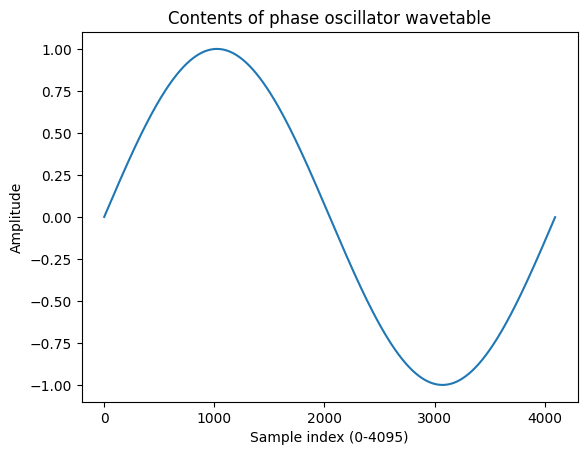

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# The wavetable will have 4096 samples as shown in the slides. We will fill it with one period of a sine wave.
WAVETABLE_SIZE = 4096
wavetable = np.sin(np.linspace(0, 2*np.pi*WAVETABLE_SIZE/(WAVETABLE_SIZE+1), WAVETABLE_SIZE))
# For fun, uncomment this to put a sawtooth wave into the wavetable. Make sure your sound volume is low before trying this!
# (This is a naive aliasing sawtooth wave because of the discontinuity at the end of each period.
# You can hear high-frequency inharmonic aliasing because of this.)
# wavetable = np.linspace(1.0, -1.0, WAVETABLE_SIZE)

fig, ax = plt.subplots()
ax.plot(wavetable)
ax.set_title("Contents of phase oscillator wavetable")
ax.set_ylabel("Amplitude")
ax.set_xlabel(f"Sample index (0-{WAVETABLE_SIZE-1})")
plt.show()

Now we need to set up the generator sampling rate and the oscillator frequency. We keep the sample rate constant--a typical sample rate would be 44.1 or 48 kHz. Here, we use 48 kHz.

The oscillator frequency determines the contents of the frequency register and therefore the pitch of the output sound. The contents of the frequency register and phase register are fractional--the frequency register value is constant, $f/f_s$.

In [33]:
generator_fs = 48000
osc_freq = 440.0  # Set the frequency in Hz here

# Freq register and phase register will be 64-bit fractional. Phase register is initialized to 0.
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

Now we're ready to generate sound. We'll produce 2 seconds of output audio.

In [ ]:
# Initialize empty output array of 2 second duration
duration = 2.0
output = np.zeros((int(generator_fs*duration)), dtype=np.float64)

# Fill in each sample for 2 seconds of audio
for i in range(1, output.shape[-1]):
    # The fmod operation simulates what happens when the fractional register reaches 1.0 and wraps around.
    phase_register = np.fmod(phase_register + freq_register, 1.0)

    # This is analogous to taking the top 12 bits of the phase register.
    index = int(np.floor(phase_register * WAVETABLE_SIZE))
    
    output[i] = wavetable[index]

Now that we've filled an array with output audio, we want to play it. We could write it to a WAV audio file using the `soundfile` or `pedalboard` libraries. Here, we'll just make an audio player directly.

In [35]:
# Sound player courtesy of Minje Kim in UIUC CS department
def sound_player( x, rate=8000, label=''):
    from IPython.display import display, Audio, HTML
    display( HTML( 
    '<style> table, th, td {border: 0px; }</style> <table><tr><td>' + label + 
    '</td><td>' + Audio( x, rate=rate)._repr_html_()[3:] + '</td></tr></table>'
    ))

sound_player(output, generator_fs, "Phase oscillator output")

Phase oscillator output,Your browser does not support the audio element.


We can plot the output of the phase oscillator. Notice that the sample indices have changed relative to the wavetable, since we're playing back at a different frequency.

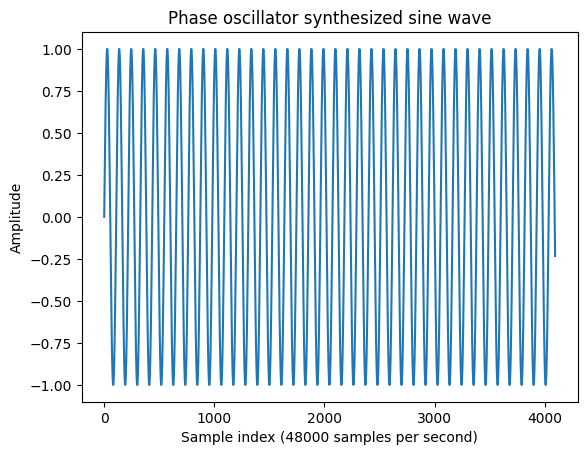

In [36]:
fig, ax = plt.subplots()
ax.plot(output[:WAVETABLE_SIZE])
ax.set_title("Phase oscillator synthesized sine wave")
ax.set_ylabel("Amplitude")
ax.set_xlabel(f"Sample index ({generator_fs} samples per second)")
plt.show()

We notice that there's an annoying click at the end where the waveform stops without returning to 0.0. We can fix this with a fadeout.

In [37]:
output[-1024:] *= np.linspace(1.0, 0.0, 1024)
sound_player(output, generator_fs, "Adjusted phase oscillator output")

Adjusted phase oscillator output,Your browser does not support the audio element.


You might want to experiment with filling the wavetable with something other than a sine wave.

**WARNING!** If you do this, be careful to keep the values in the wavetable between -1.0 and 1.0. And always start with the volume at a low level for safety. Remember, loud sounds can damage your hearing!

## Phase Oscillator Spectrum

We can look at the spectrum of the phase oscillator output to help verify that it is producing the right frequency, and to see aliasing. First we'll look at the spectrum of the entire output.

The phase oscillator does not interpolate between samples to improve the signal quality, so aliasing is a potential issue. If you're using the basic sine wavetable along with the fadeout at the end of the sound, this spectrum should look pretty good, though.

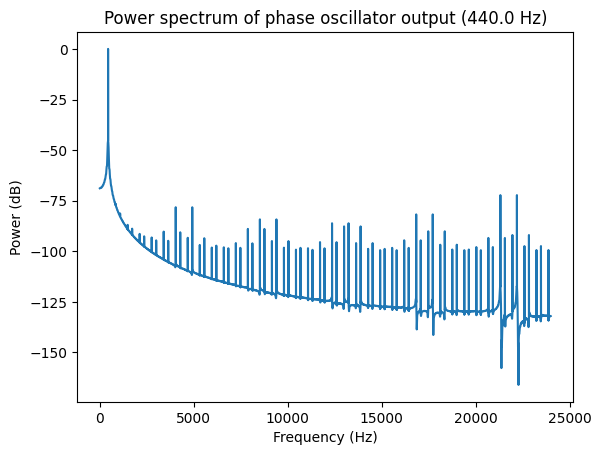

In [38]:
import numpy.fft as fft
power_spec = np.square(np.abs(fft.rfft(output), dtype=np.float64))
logspec = 10 * np.log10(power_spec/np.max(power_spec))
freqs = fft.rfftfreq(output.shape[-1], 1/generator_fs)
fig, ax = plt.subplots()
ax.plot(freqs, logspec)
ax.set_title(f"Power spectrum of phase oscillator output ({osc_freq} Hz)")
ax.set_ylabel("Power (dB)")
ax.set_xlabel("Frequency (Hz)")
plt.show()

We can also make a spectrogram to see if the spectrum changes over time. It should essentially be consistent for the entire duration of the sound.

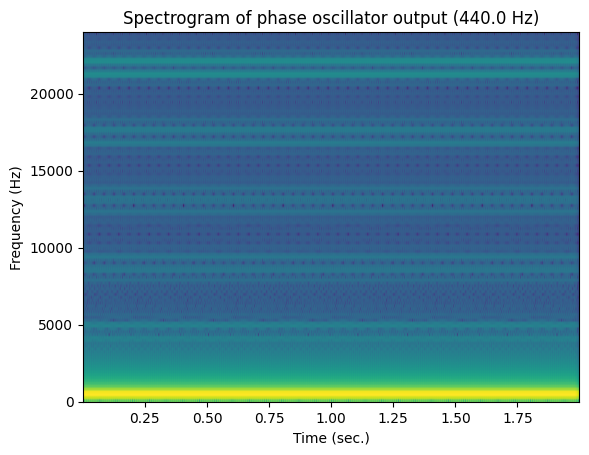

In [39]:
fig, ax = plt.subplots()
ax.specgram(output, Fs=generator_fs)
ax.set_title(f"Spectrogram of phase oscillator output ({osc_freq} Hz)")
ax.set_xlabel("Time (sec.)")
ax.set_ylabel("Frequency (Hz)")
plt.show()

## ADSR Envelopes

When we generate a sound, we don't want it to continue forever. We often apply an ADSR envelope to the sound because of this. ADSR stands for "attack, decay, sustain, release." Here we'll use a 1-second ADSR envelope, with a 10ms attack, 20ms decay, 800ms sustain, and 170ms release. The attack level will be 1.0, and sustain level will be 0.3.

In [40]:
generator_fs = 48000
osc_freq = 440.0
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

duration = 1.0
output = np.zeros((int(generator_fs*duration)), dtype=np.float64)

for i in range(1, output.shape[-1]):
    phase_register = np.fmod(phase_register + freq_register, 1.0)
    index = int(np.floor(phase_register * WAVETABLE_SIZE))    
    output[i] = wavetable[index]

envelope = np.concatenate((
    np.linspace(0.0, 1.0, int(generator_fs * 0.01)), # attack
    np.linspace(1.0, 0.3, int(generator_fs * 0.02)), # decay
    np.linspace(0.3, 0.3, int(generator_fs * 0.8)),  # sustain
    np.linspace(0.3, 0.0, int(generator_fs * 0.17)), # release
))

output = output * envelope
sound_player(output, generator_fs, "Phase oscillator with ADSR envelope")

Phase oscillator with ADSR envelope,Your browser does not support the audio element.


## Chords

We can play a chord by running several phase oscillators in parallel. Here's an example.

In [41]:
generator_fs = 48000

duration = 1.0

# 3 output buffers, one for each pitch in the chord
output1 = np.zeros((int(generator_fs*duration)), dtype=np.float64)
output2 = np.zeros((int(generator_fs*duration)), dtype=np.float64)
output3 = np.zeros((int(generator_fs*duration)), dtype=np.float64)

# Lowest pitch in the chord, 220 Hz.
osc_freq = 220.0
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

for i in range(1, output1.shape[-1]):
    phase_register = np.fmod(phase_register + freq_register, 1.0)
    index = int(np.floor(phase_register * WAVETABLE_SIZE))    
    output1[i] = wavetable[index]

# Middle pitch in the chord, a just major third.
osc_freq = 220.0 * 5/4
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

for i in range(1, output2.shape[-1]):
    phase_register = np.fmod(phase_register + freq_register, 1.0)
    index = int(np.floor(phase_register * WAVETABLE_SIZE))    
    output2[i] = wavetable[index]

# Highest pitch in the chord, a just perfect fifth.
osc_freq = 220.0 * 3/2
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

for i in range(1, output3.shape[-1]):
    phase_register = np.fmod(phase_register + freq_register, 1.0)
    index = int(np.floor(phase_register * WAVETABLE_SIZE))    
    output3[i] = wavetable[index]

# Sum the three output pitches into a chord, and normalize the volume to avoid clipping
output = (output1 + output2 + output3) / 3

# Apply the ADSR envelope to the sound
envelope = np.concatenate((
    np.linspace(0.0, 1.0, int(generator_fs * 0.01)), # attack
    np.linspace(1.0, 0.3, int(generator_fs * 0.02)), # decay
    np.linspace(0.3, 0.3, int(generator_fs * 0.8)),  # sustain
    np.linspace(0.3, 0.0, int(generator_fs * 0.17)), # release
))
output = output * envelope
sound_player(output, generator_fs, "Phase oscillator with ADSR envelope")

Phase oscillator with ADSR envelope,Your browser does not support the audio element.
